# Librerías

In [255]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import xarray as xr
import pandas as pd
import numpy as np

from pathlib import Path

import dask.array as da
from spectralcrop import PathManager

# --- Geoespacial ---
import rioxarray
import geopandas as gpd
import rasterio
from rasterio import features
from affine import Affine

# --- Visualización ---
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch



import geopandas as gpd
from sklearn.model_selection import train_test_split

In [3]:
interim_data = PathManager().get_abs_path_folder("interim")
zarr_path = interim_data + "masked_reflectance.zarr"

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

def nearest_band_index(wavelengths_nm, target_nm):
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    idx = int(np.abs(wavelengths_nm - target_nm).argmin())
    return idx, float(wavelengths_nm[idx])

# Cargar información

## Cubo de datos

In [62]:
ds = xr.open_zarr(zarr_path, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]
nodata_mask = ds["mask_nodata"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")



<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_22396\4113903066.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(zarr_path, chunks={"band": 64, "y": 512, "x": 512})


In [63]:
# Contar NaNs por píxel en reflectancia
nan_counts = refl_byx.isnull().sum(dim=["y", "x"])  # suma sobre y y x

In [64]:
print(nan_counts.values.max(), nan_counts.values.min())

6432671 6411637


In [65]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = refl_byx.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")


Píxeles con ≥1 NaN: 6484992 (51.54%)


In [76]:
veg_mask

<xarray.DataArray 'veg_mask' (y: 3660, x: 3438)> Size: 13MB
dask.array<astype, shape=(3660, 3438), dtype=bool, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    0:                  no-veg
    1:                  veg
    dimension_names:    ['y', 'x']
    _ARRAY_DIMENSIONS:  ['y', 'x']

In [95]:
# Pixeles válidos - vegetación
(veg_mask == 1).values.sum().sum() 

np.int64(6127993)

In [96]:
# Pixeles inválidos - vegetación
(veg_mask == 1).shape[0]*(veg_mask == 1).values.shape[1] - (veg_mask == 1).values.sum().sum()

np.int64(6455087)

In [91]:
nodata_mask

<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  NoData mask (0=valid, 1=NoData)
    source:     c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\int...

In [97]:
# Pixeles válidos - no datos
(nodata_mask == 0).values.sum().sum()

np.int64(6098088)

In [98]:
# Pixeles inválidos - no datos
(nodata_mask == 0).shape[0]*(nodata_mask == 0).values.shape[1] - (nodata_mask == 0).values.sum().sum()

np.int64(6484992)

In [99]:
# -----------------------------
# Máscaras validadas para datos
# -----------------------------

valid_mask = (veg_mask & (nodata_mask == 0))
valid_mask.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [194]:
# Pixeles válidos
valid_mask.values.sum().sum()

np.int64(6055113)

In [101]:
# Pixeles inválidos
valid_mask.values.shape[0]*valid_mask.values.shape[1] - valid_mask.values.sum().sum()

np.int64(6527967)

Pixeles válidos: 6,055,113 (48.12%)


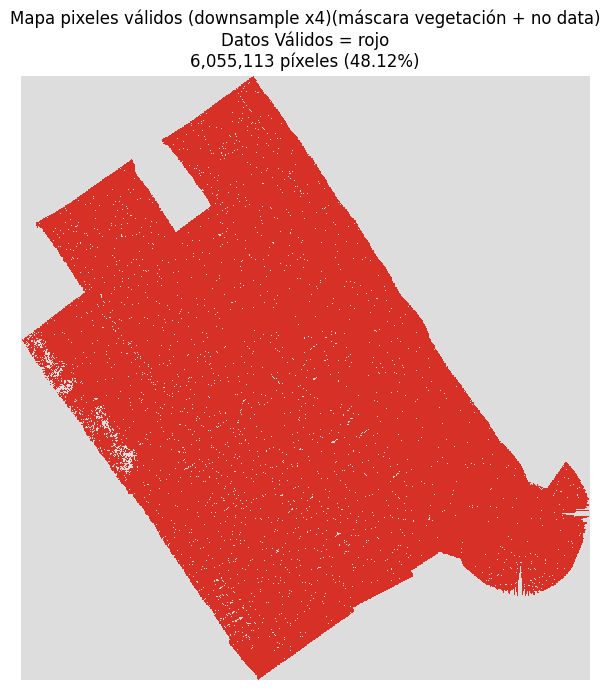

In [200]:
# --- Mapa visual de píxeles NoData (y superposición opcional de veg_mask) ---


# 2) Estadísticos rápidos
total_px = valid_mask.sizes["y"] * valid_mask.sizes["x"]
nodata_px = int(valid_mask.sum().compute())
nodata_pct = 100.0 * nodata_px / total_px
print(f"Pixeles válidos: {nodata_px:,} ({nodata_pct:.2f}%)")

# 3) Preparar una versión reducida para visualización rápida (downsample)
stride = 4
nodata_vis = valid_mask.isel(y=slice(None, None, stride),
                               x=slice(None, None, stride))

# 4) Visualización binaria clara (NoData=1 en rojo, Data=0 en gris claro)
cmap_bin = ListedColormap(["#dddddd", "#d73027"])  # data=gris, NoData=rojo

plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap=cmap_bin, interpolation="nearest")
plt.title(f"Mapa pixeles válidos (downsample x{stride})(máscara vegetación + no data)\nDatos Válidos = rojo\n{nodata_px:,} píxeles ({nodata_pct:.2f}%)")
plt.axis("off")
plt.tight_layout()
# plt.savefig(FIGURES_FOLDER + "/nodata_map_binary.png", dpi=150)
plt.show()

## Etiquetas

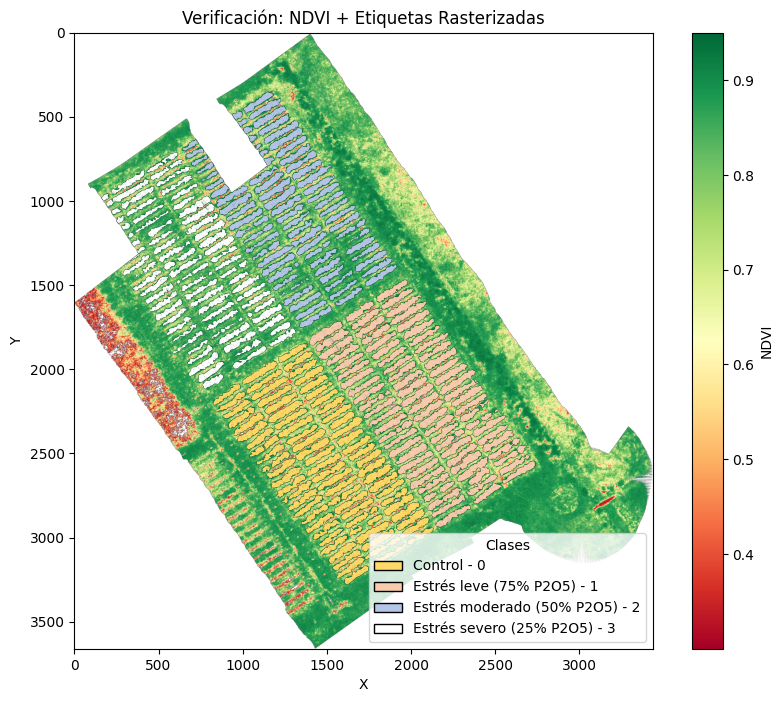

In [102]:
# --- Rutas ---
labels_tiff_path = Path(PathManager().get_abs_path_file("labels_multiclass.tif"))

ndvi = ds["NDVI"].compute()  # Cargar NDVI en memoria para graficar

# --- Obtener transform y CRS ---
crs = ndvi.rio.crs
transform = ndvi.rio.transform()
height, width = ndvi.shape

# Calcular extent para imshow
x_min = transform.c
x_max = transform.c + width * transform.a
y_max = transform.f
y_min = transform.f + height * transform.e  # e es negativo
extent = (x_min, x_max, y_min, y_max)

# --- Abrir GeoTIFF de etiquetas ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)

# --- Graficar overlay ---
fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(ndvi, cmap="RdYlGn", extent=extent, origin="upper")


# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estrés leve (75% P2O5) - 1",
    2: "Estrés moderado (50% P2O5) - 2",
    3: "Estrés severo (25% P2O5) - 3",
}
colors = ["#FFD966", "#F8CBAD", "#B4C6E7", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

masked_labels = np.ma.masked_where(labels == 255, labels)
ax.imshow(masked_labels, cmap=cmap_labels, alpha=1, extent=extent, origin="upper")

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación: NDVI + Etiquetas Rasterizadas")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.colorbar(img, ax=ax, label="NDVI")
plt.show()

In [105]:
# --- Abrir etiquetas como array ---
with rasterio.open(labels_tiff_path) as src:
    labels = src.read(1)  # numpy array (y, x)

# Convertir a binario: 0 = control, resto (1,2,3) = enfermo
labels_bin = np.where(labels == 0, 0, 
                      np.where(
                          np.isin(labels, [1, 2, 3]), 1, np.nan
                        )
                    )

# Aplicar máscara veg-valid
labels_bin = np.where(valid_mask, labels_bin, np.nan)

In [106]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

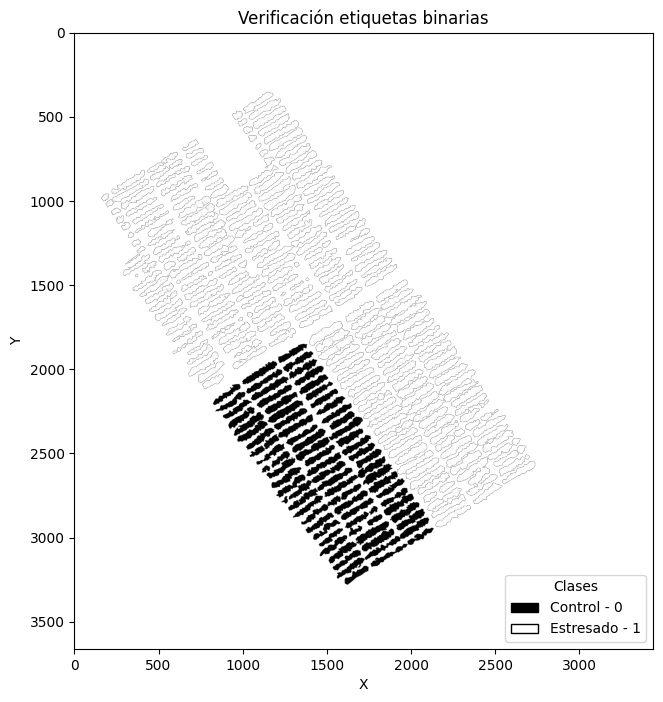

In [225]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

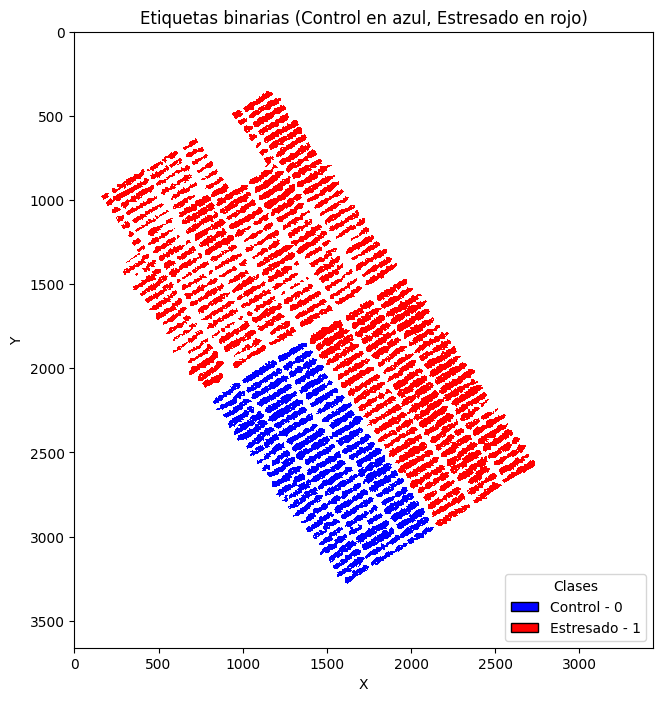

In [223]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()


In [229]:
np.isnan(labels_bin).sum()

np.int64(10834441)

In [231]:
labels_bin.shape[0] * labels_bin.shape[1] - np.isnan(labels_bin).sum()

np.int64(1748639)

In [3]:
3660*3438

12583080

In [4]:
1748639/12583080

0.1389674864977414

# 1. Preparación de datos

## 1.1 Preparar matriz de características X

In [108]:
# -----------------------------
# 5. Extraer índices espectrales y bandas clave
# -----------------------------
# Índices ya calculados en Zarr: NDVI, NDRE, CIgreen, PRI, PSRI
indices = ds[["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]]

# Selección de bandas clave (ejemplo: Red, NIR, Red-Edge)
wavelengths = ds["wavelength"].values
band_names = ["Red", "NIR", "RedEdge"]
target_waves = [670, 800, 720]  # aproximadas
selected_bands = []
for tw in target_waves:
    idx = np.argmin(np.abs(wavelengths - tw))
    selected_bands.append(idx)

reflectance_selected = ds["reflectance"].isel(band=selected_bands)
reflectance_selected

<xarray.DataArray 'reflectance' (band: 3, y: 3660, x: 3438)> Size: 151MB
dask.array<getitem, shape=(3, 3660, 3438), dtype=float32, chunksize=(3, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 12B 89 134 106
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']

In [109]:
indices_da = indices.to_array(dim="band")
indices_da

<xarray.DataArray (band: 5, y: 3660, x: 3438)> Size: 252MB
dask.array<stack, shape=(5, 3660, 3438), dtype=float32, chunksize=(1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 40B 'NDVI' 'NDRE' 'CIgreen' 'PRI' 'PSRI'
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [147]:
nan_counts = indices_da.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)

[6527967 6528031 7596119 7071551 6575062]


In [153]:
# "NDVI", "NDRE", "CIgreen", "PRI", "PSRI"
(~indices_da.isnull()).sum(dim=["y", "x"]).values

# -> CIgreen tiene más NaN que el resto

array([6055113, 6055049, 4986961, 5511529, 6008018])

In [110]:
# -----------------------------
# 6. Construir DataFrame para ML
# -----------------------------
# Aplanar datos válidos
features_stack = xr.concat([indices_da, reflectance_selected], dim="band")
features_stack = features_stack.transpose("y", "x", "band")
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 8)> Size: 403MB
dask.array<transpose, shape=(3660, 3438, 8), dtype=float32, chunksize=(512, 512, 3), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 64B 'NDVI' 'NDRE' 'CIgreen' 'PRI' 'PSRI' 89 134 106
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [111]:
nan_counts = features_stack.isnull().sum(dim=["y", "x"])  # suma sobre y y x
print(nan_counts.values)


[6527967 6528031 7596119 7071551 6575062 6411637 6411637 6411637]


In [112]:

print("Size features:", features_stack.sizes)
print("Size labels:", labels_bin.shape)


Size features: Frozen({'y': 3660, 'x': 3438, 'band': 8})
Size labels: (3660, 3438)


In [113]:
features_stack

<xarray.DataArray (y: 3660, x: 3438, band: 8)> Size: 403MB
dask.array<transpose, shape=(3660, 3438, 8), dtype=float32, chunksize=(512, 512, 3), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 64B 'NDVI' 'NDRE' 'CIgreen' 'PRI' 'PSRI' 89 134 106
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [114]:
labels_bin.shape[0]*labels_bin.shape[1]

12583080

In [121]:
# Máscara para extraer solo píxeles válidos
valid_pixels = valid_mask #& ~np.isnan(labels_bin)
valid_pixels.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [211]:
# Extraer valores
X = features_stack.where(valid_pixels)#.values.reshape(-1, features_stack.shape[-1])
X

<xarray.DataArray (y: 3660, x: 3438, band: 8)> Size: 403MB
dask.array<where, shape=(3660, 3438, 8), dtype=float32, chunksize=(512, 512, 3), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) object 64B 'NDVI' 'NDRE' 'CIgreen' 'PRI' 'PSRI' 89 134 106
Dimensions without coordinates: y, x
Attributes:
    crs:        EPSG:32618
    transform:  [0.02, 0.0, 453983.38, 0.0, -0.02, 677786.01, 0.0, 0.0, 1.0]

In [183]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = ds['reflectance'].isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6484992 (51.54%)


In [184]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = reflectance_selected.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 6411637 (50.95%)


In [185]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = indices_da.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


In [186]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = features_stack.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100



print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")
print(f"Píxeles válidos: {features_stack.shape[0]*features_stack.shape[1] - count_nan_pixels}")

Píxeles con ≥1 NaN: 7596119 (60.37%)
Píxeles válidos: 4986961


In [187]:
# Porcentaje NaN por píxel (≥1 NaN en alguna banda) (El pixel tiene al menos 1 NaN)
mask_nan_pixel = X.isnull().any(dim="band")  # dims: y, x
count_nan_pixels = mask_nan_pixel.values.sum().item()  # convertir a escalar Python
total_pixels = mask_nan_pixel.size  # y*x
percentage = (count_nan_pixels / total_pixels) * 100

print(f"Píxeles con ≥1 NaN: {count_nan_pixels} ({percentage:.2f}%)")

Píxeles con ≥1 NaN: 7596119 (60.37%)


Voy a enmascarar los labels para que coincidan con X

In [234]:
X.isnull().any(dim="band").values

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(3660, 3438))

In [235]:
labels_bin

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

In [236]:

# Enmascarar: donde mask_nan_pixels == True -> NaN
labels_bin_masked = np.where(X.isnull().any(dim="band").values, np.nan, labels_bin)
labels_bin_masked

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(3660, 3438))

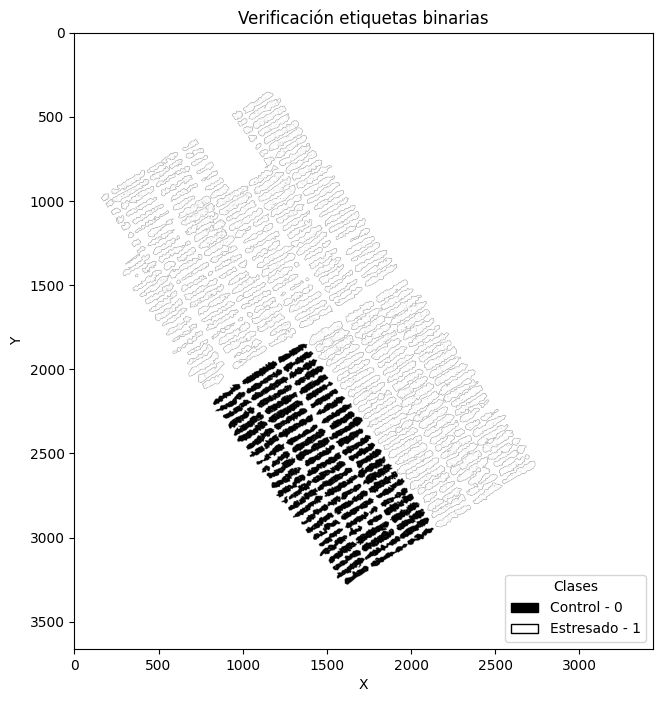

In [237]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(labels_bin_masked, cmap="gray", extent=extent, origin="upper")

# Overlay etiquetas con transparencia
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#000000", "#FFFFFF"]  # Colores para cada clase
cmap_labels = ListedColormap(colors)

# --- Crear leyenda ---
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Verificación etiquetas binarias")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()


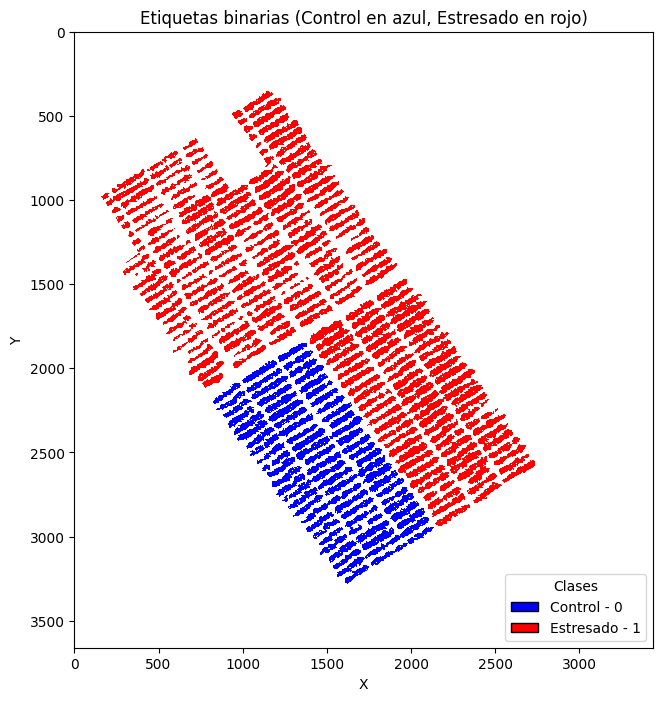

In [238]:
fig, ax = plt.subplots(figsize=(10, 8))

# Colores: azul para control, rojo para estresado
classes = {
    0: "Control - 0",
    1: "Estresado - 1",
}
colors = ["#0000FF", "#FF0000"]  # Azul, Rojo
cmap_labels = ListedColormap(colors)

# Graficar etiquetas binarias
im = ax.imshow(labels_bin_masked, cmap=cmap_labels, vmin=0, vmax=1,
               extent=extent, origin="upper", interpolation="nearest")

# Leyenda
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=classes[i]) for i in classes]
ax.legend(handles=legend_elements, title="Clases", loc="lower right")

ax.set_title("Etiquetas binarias (Control en azul, Estresado en rojo)")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

In [239]:
np.isnan(labels_bin_masked).sum()

np.int64(10868816)

In [240]:
labels_bin_masked.shape[0] * labels_bin_masked.shape[1] - np.isnan(labels_bin_masked).sum()

np.int64(1714264)

Hay 1714264 labels que tienen todos los features válidos y  además tienen etiqueta válida (0 o 1).

In [241]:
X = X.values.reshape(-1, features_stack.shape[-1])
X

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(12583080, 8), dtype=float32)

In [242]:
labels_bin.reshape(-1)

array([nan, nan, nan, ..., nan, nan, nan], shape=(12583080,))

In [243]:
data = np.concatenate([X, labels_bin.reshape(-1, 1)], axis=1)
data

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(12583080, 9))

In [244]:
X[0]

array([nan, nan, nan, nan, nan, nan, nan, nan], dtype=float32)

In [245]:
pd.DataFrame(data).head()

,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [246]:
pd.DataFrame(X).shape[0] - pd.DataFrame(X).isna().sum()

# La columna que corresponde a CIgreen tiene más NaN que el resto

0    6055113
1    6055049
2    4986961
3    5511529
4    6008018
5    6055113
6    6055113
7    6055113
dtype: int64

In [247]:
pd.DataFrame(X).dropna(axis=0, how='any')

# CIgreen tiene más NaN que el resto, por tanto controla el shape final de X

,0,1,2,3,4,5,6,7
18591,0.876371,0.388399,6.273077,-0.033175,0.004831,6.700000e-07,0.000018,0.000007
18592,0.880613,0.424105,7.569306,-0.042424,0.003342,5.100000e-07,0.000017,0.000006
22027,0.888262,0.451585,8.156757,-0.039216,0.002761,4.500000e-07,0.000016,0.000006
22028,0.882353,0.408375,6.766949,-0.036082,0.003781,5.700000e-07,0.000018,0.000007
22029,0.875403,0.411955,6.768888,-0.040650,0.003309,6.000000e-07,0.000017,0.000006
...,...,...,...,...,...,...,...,...
12567322,0.878031,0.306926,4.498925,-0.011704,-0.002907,1.040000e-06,0.000025,0.000012
12567323,0.881054,0.312920,4.516737,-0.011613,-0.000798,1.090000e-06,0.000026,0.000012
12567324,0.883433,0.338011,4.973154,-0.005571,-0.002783,1.050000e-06,0.000026,0.000012
12570760,0.879377,0.310884,4.751773,-0.004172,-0.000444,9.300000e-07,0.000024,0.000011


In [249]:
data_ = pd.DataFrame(data).dropna(axis=0, how='any')
data_ 

,0,1,2,3,4,5,6,7,8
1204447,0.867777,0.302103,4.585443,-0.015810,0.001253,6.800000e-07,0.000017,0.000009,1.0
1204448,0.881944,0.299696,4.794038,-0.013333,0.002048,8.000001e-07,0.000021,0.000010,1.0
1207884,0.853725,0.327300,5.055046,-0.034286,0.006050,5.300000e-07,0.000013,0.000006,1.0
1207885,0.875657,0.302154,4.496104,-0.022801,0.002082,8.500000e-07,0.000021,0.000010,1.0
1207886,0.880990,0.303333,4.520000,-0.013413,-0.000465,9.100000e-07,0.000023,0.000011,1.0
...,...,...,...,...,...,...,...,...,...
11264513,0.888521,0.366129,7.144231,-0.015290,0.001305,5.200000e-07,0.000017,0.000007,0.0
11264514,0.882600,0.398624,8.368794,-0.027027,0.003433,3.200000e-07,0.000013,0.000005,0.0
11267949,0.861718,0.342920,5.820225,0.004504,0.000000,8.200000e-07,0.000018,0.000008,0.0
11267950,0.844688,0.332175,5.390000,0.000000,-0.001731,1.040000e-06,0.000019,0.000009,0.0


## 1.2 Separar X y y validados

In [250]:
X = data_.iloc[:, :-1].values
y = data_.iloc[:, -1].values

In [251]:
X

array([[8.67777169e-01, 3.02102536e-01, 4.58544350e+00, ...,
        6.80000028e-07, 1.74399993e-05, 8.56999941e-06],
       [8.81944418e-01, 2.99696028e-01, 4.79403782e+00, ...,
        8.00000066e-07, 2.11799997e-05, 1.03399998e-05],
       [8.53725135e-01, 3.27300131e-01, 5.05504608e+00, ...,
        5.29999966e-07, 1.30600001e-05, 5.95999973e-06],
       ...,
       [8.61718357e-01, 3.42920303e-01, 5.82022476e+00, ...,
        8.20000025e-07, 1.78099999e-05, 7.89000023e-06],
       [8.44687939e-01, 3.32175136e-01, 5.39000034e+00, ...,
        1.04000003e-06, 1.88600006e-05, 8.56999941e-06],
       [8.59078526e-01, 3.44936728e-01, 6.05394220e+00, ...,
        7.30000011e-07, 1.66499995e-05, 7.28999976e-06]],
      shape=(1714264, 8))

In [252]:
y

array([1., 1., 1., ..., 0., 0., 0.], shape=(1714264,))

In [253]:
print(f"Shape X: {X.shape}, Shape y: {y.shape}, Clases: {np.unique(y)}")    

Shape X: (1714264, 8), Shape y: (1714264,), Clases: [0. 1.]


In [259]:
pd.Series(y).value_counts()

1.0    1224210
0.0     490054
Name: count, dtype: int64

## 1.3 Split de datos en train/test (sin spatial split aún)

In [260]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Submuestreo para balancear
# -----------------------------
rus = RandomUnderSampler(random_state=42)
X_bal, y_bal = rus.fit_resample(X, y)
print("Distribución balanceada:", dict(zip(*np.unique(y_bal, return_counts=True))))

# -----------------------------
# 2. División train/test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, stratify=y_bal, random_state=42)

# -----------------------------
# 3. Escalado robusto
# -----------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Distribución balanceada: {np.float64(0.0): np.int64(490054), np.float64(1.0): np.int64(490054)}


# 2. Modelado con XGBoost

## 2.1 Modelo base sin optimización de hiperparámetros


--- Reporte de clasificación ---
              precision    recall  f1-score   support

         0.0      0.552     0.627     0.587    147017
         1.0      0.568     0.491     0.527    147016

    accuracy                          0.559    294033
   macro avg      0.560     0.559     0.557    294033
weighted avg      0.560     0.559     0.557    294033

ROC-AUC: 0.584

Matriz de confusión:
[[92235 54782]
 [74859 72157]]


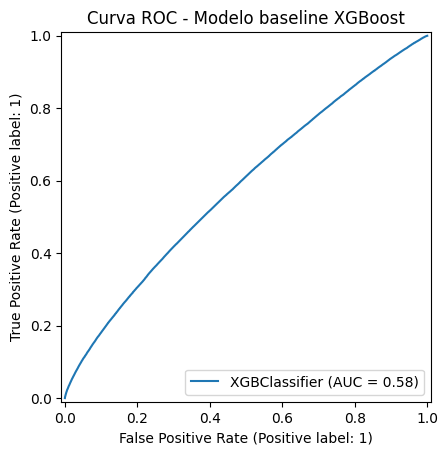

In [261]:
# -----------------------------
# 4. Modelo XGBoost
# -----------------------------
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)

# -----------------------------
# 5. Predicciones y métricas
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Reporte de clasificación ---")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# 6. Curva ROC
# -----------------------------
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("Curva ROC - Modelo baseline XGBoost")
plt.show()

## 2.2 Optimización de hiperparámetros

Fitting 3 folds for each of 30 candidates, totalling 90 fits

Mejores parámetros encontrados:
  xgb__subsample: 0.6
  xgb__reg_lambda: 2.5118864315095797
  xgb__reg_alpha: 1.0
  xgb__n_estimators: 600
  xgb__min_child_weight: 2
  xgb__max_depth: 5
  xgb__learning_rate: 0.054285714285714284
  xgb__gamma: 1.0
  xgb__colsample_bytree: 1.0
Mejor ROC-AUC (CV): 0.581

--- Reporte de clasificación (Test) ---
              precision    recall  f1-score   support

         0.0      0.330     0.628     0.433    147016
         1.0      0.767     0.491     0.599    367264

    accuracy                          0.530    514280
   macro avg      0.549     0.559     0.516    514280
weighted avg      0.642     0.530     0.551    514280

ROC-AUC (Test): 0.584

Matriz de confusión (Test):
[[ 92291  54725]
 [187019 180245]]


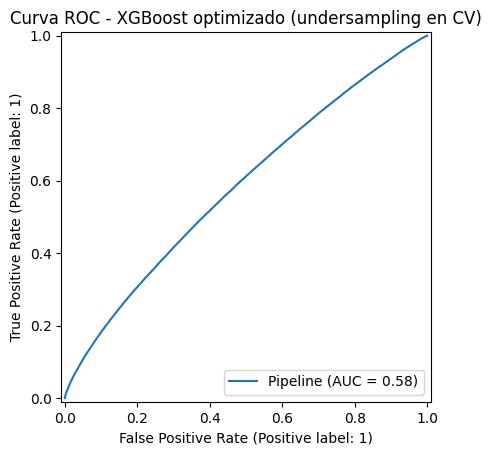

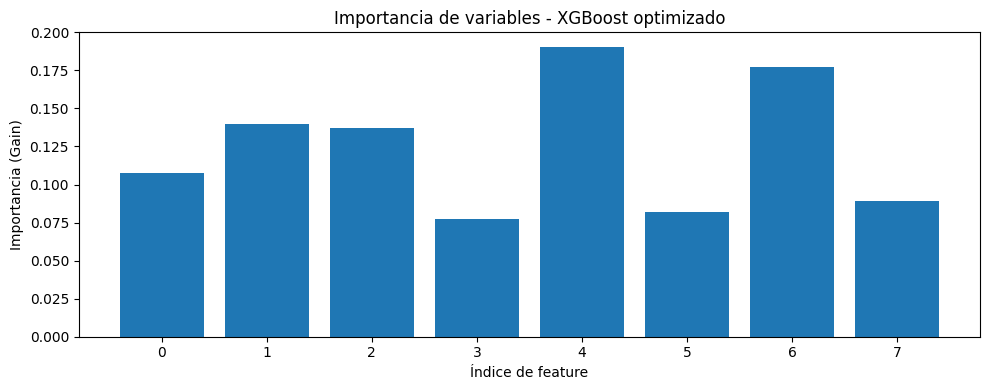

In [262]:

# ==============================
# Optimización rápida XGBoost
# Submuestreo dentro de CV
# ==============================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import RobustScaler

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# -----------------------------
# 1) Holdout test estratificado
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# -----------------------------
# 2) Pipeline: undersample + (opcional) scaler + XGB
# -----------------------------
pipeline = ImbPipeline(steps=[
    ('rus', RandomUnderSampler(random_state=42)),
    ('scaler', RobustScaler(with_centering=True, with_scaling=True)),
    ('xgb', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        tree_method='hist',   # rápido
        eval_metric='logloss' # métrica interna de XGB (no afecta a scoring de sklearn)
        # scale_pos_weight lo fijamos en 1 porque ya balanceamos con undersampling
    ))
])

# -----------------------------
# 3) Espacio de búsqueda
# -----------------------------
param_dist = {
    'xgb__n_estimators': np.arange(200, 801, 100),      # 200–800
    'xgb__max_depth': np.arange(3, 10),                 # 3–9
    'xgb__learning_rate': np.linspace(0.03, 0.2, 8),    # 0.03–0.2
    'xgb__min_child_weight': np.arange(1, 7),           # 1–6
    'xgb__subsample': np.linspace(0.6, 1.0, 5),         # 0.6–1.0
    'xgb__colsample_bytree': np.linspace(0.6, 1.0, 5),  # 0.6–1.0
    'xgb__gamma': np.linspace(0.0, 3.0, 7),             # regularización de partición
    'xgb__reg_lambda': np.logspace(-2, 1, 6),           # L2: 0.01–10
    'xgb__reg_alpha': np.logspace(-3, 0, 5),            # L1: 0.001–1
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,                 # combinaciones a probar (ajusta según tiempo)
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

# -----------------------------
# 4) Ejecutar búsqueda
# -----------------------------
search.fit(X_train, y_train)

print("\nMejores parámetros encontrados:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Mejor ROC-AUC (CV): {search.best_score_:.3f}")

# -----------------------------
# 5) Evaluación en holdout test
# -----------------------------
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n--- Reporte de clasificación (Test) ---")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC (Test): {roc_auc:.3f}")

print("\nMatriz de confusión (Test):")
print(confusion_matrix(y_test, y_pred))

# Curva ROC
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Curva ROC - XGBoost optimizado (undersampling en CV)")
plt.show()

# -----------------------------
# 6) Importancia de features (opcional)
# -----------------------------
# OJO: si tienes scaler/undersampling en el pipeline, extrae el paso 'xgb'
xgb_step = best_model.named_steps['xgb']
importances = xgb_step.feature_importances_

plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances)
plt.xlabel("Índice de feature")
plt.ylabel("Importancia (Gain)")
plt.title("Importancia de variables - XGBoost optimizado")
plt.tight_layout()
plt.show()


# Resumen: Baseline Model – Clasificación Binaria (Control vs Estrés por P)

## Objetivo:
Evaluar la capacidad inicial de discriminación entre plantas de frijol común (Phaseolus vulgaris L.) con fertilización completa (control) y aquellas sometidas a estrés por fósforo (clases 1, 2 y 3 agrupadas).

## Datos utilizados

- Etiquetas: Raster binario derivado de polígonos experimentales (0 = control, 1 = estresado).
- Máscara aplicada: Vegetación válida (veg_mask & mask_nodata==0).
- Features:
        - Índices espectrales: NDVI, NDRE, CIgreen, PRI, PSRI.
        - Bandas seleccionadas: Rojo (~670 nm), Red-Edge (~720 nm), NIR (~800 nm).
        - Total: 8 variables.


## Preprocesamiento:

- muestreo aleatorio para balancear clases.
- alado robusto (RobustScaler).
- isión train/test: 70/30 (sin split espacial en esta fase).

## Modelo

- Algoritmo: XGBoost (XGBClassifier).
- Optimización:

    - RandomizedSearchCV (30 combinaciones, 3-fold CV, métrica ROC-AUC).
    - Hiperparámetros óptimos:
        - n_estimators=600, max_depth=5, learning_rate≈0.054,
        - subsample=0.6, colsample_bytree=1.0,
        - gamma=1.0, min_child_weight=2,
        - reg_alpha=1.0, reg_lambda≈2.51.

## Resultados

- ROC-AUC (CV): 0.581
- ROC-AUC (Test): 0.584
- Accuracy: 0.53
- Reporte de clasificación (Test):
    - Clase 0 (Control): Precision=0.33, Recall=0.63, F1=0.43
    - Clase 1 (Estresado): Precision=0.77, Recall=0.49, F1=0.60


- Matriz de confusión:

    - Control correctamente clasificado: 92,291
    - Estresado correctamente clasificado: 180,245
    - Falsos negativos (estresado → control): 187,019


- Curva ROC: AUC ≈ 0.58 (ligeramente mejor que azar).
- Importancia de variables:

    - Mayor peso en bandas Red-Edge y NIR, seguido por NDRE y PRI.


## Interpretación

- El modelo baseline muestra discriminación limitada (AUC ≈ 0.58), indicando que:
    - Existe señal espectral relacionada con el estrés por fósforo.
    - Pero la separación entre clases es débil, posiblemente por:
        - Variabilidad interna en la clase “estresado” (agrupa leve, moderado, severo).
        - Features limitadas (solo índices y pocas bandas).
        - Split aleatorio (riesgo de leakage espacial).


## Conclusión

El baseline es útil como referencia inicial, pero requiere mejoras:

- Split espacial por polígonos.
- Ampliación y selección de features.
- Balanceo por pesos (scale_pos_weight) en lugar de submuestreo.
- Modelos más complejos o feature engineering avanzado